In [1]:
#Import necessary packages
import glob
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score

In [2]:
# Get a sorted list of all Tahoe confidence metric CSV files
files = sorted(glob.glob("data/tahoe_confidence_metrics/*_tahoe_confidence_metrics.csv"))

dfs = []  # store cleaned dataframes for each protein

for fp in files:
    # Read each file
    df = pd.read_csv(fp)

    # Keep only relevant columns for downstream analysis
    df = df[["index", "norm_confidence"]].copy()

    # Extract protein name from filename and add as a column
    df["protein"] = os.path.basename(fp).replace("_tahoe_confidence_metrics.csv", "")

    # Skip problematic datasets:
    # 1. If any high-confidence (=1) values appear too late in the index (>300)
    if ((df["norm_confidence"] == 1) & (df["index"] > 300)).any():
        continue

    # 2. If any low-confidence (=0) values appear too early in the index (<200)
    if ((df["norm_confidence"] == 0) & (df["index"] < 200)).any():
        continue

    # Keep only valid datasets
    dfs.append(df)

# Concatenate all valid protein dataframes into one
# Drop rows with missing index or confidence values
all_df = pd.concat(dfs, ignore_index=True).dropna(subset=["index", "norm_confidence"])

In [3]:
# Convert dataframe columns to NumPy arrays for curve fitting
x_all = all_df["index"].to_numpy(dtype=float)              # independent variable (rank/index)
y_all = all_df["norm_confidence"].to_numpy(dtype=float)    # dependent variable (normalized confidence)

# Define a 4-parameter logistic function
# L: amplitude (range of the curve)
# k: slope (steepness of transition)
# xmid: midpoint (inflection point)
# c: baseline offset
def logistic(x, L, k, xmid, c):
    return c + L / (1 + np.exp(k * (x - xmid)))

# Initial parameter guesses to help curve fitting converge
# L: range of y values
# k: small negative slope (assuming decreasing trend)
# xmid: median of x values (center of transition)
# c: minimum y value (baseline)
p0 = [
    np.nanmax(y_all) - np.nanmin(y_all), 
    -0.05, 
    np.median(x_all), 
    np.nanmin(y_all)
]

# Fit the logistic model to the data
# maxfev increased to allow more iterations for convergence
popt, _ = curve_fit(logistic, x_all, y_all, p0=p0, maxfev=200000)

# Generate predicted values using the fitted parameters
y_pred = logistic(x_all, *popt)

# Compute R^2 score to evaluate goodness of fit
r2 = r2_score(y_all, y_pred)

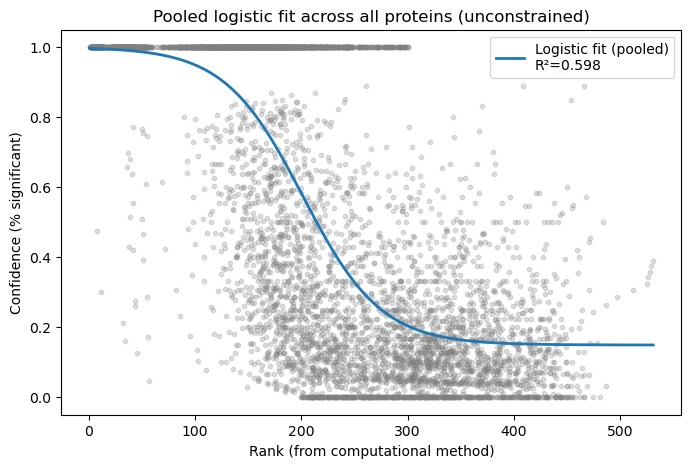

In [4]:
# Create a smooth x-range spanning the observed data for plotting the fitted curve
xs = np.linspace(np.nanmin(x_all), np.nanmax(x_all), 400)

# Initialize the figure
plt.figure(figsize=(8, 5))

# Plot raw data as a scatter:
# - small points (s=10)
# - grey color with transparency to show density
plt.scatter(x_all, y_all, s=10, color='grey', alpha=0.25)

# Plot the fitted logistic curve using optimized parameters
# - evaluated on smooth xs grid
# - include R² in legend for model fit quality
plt.plot(
    xs, 
    logistic(xs, *popt), 
    linewidth=2, 
    label=f"Logistic fit (pooled)\nR²={r2:.3f}"
)

# Axis labels describing variables
plt.xlabel("Rank (from computational method)")
plt.ylabel("Confidence (% significant)")

# Plot title describing the analysis
plt.title("Pooled logistic fit across all proteins (unconstrained)")

# Turn off grid for cleaner visual (consistent with your style)
plt.grid(False)

# Show legend (includes R²)
plt.legend()

# Display the plot
plt.show()